In [1]:
import pandas as pd
import seaborn as sns

raw_data = pd.read_csv('rba-dataset.csv')
raw_data

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,43:30.8,-4.324480e+18,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,43:43.5,-4.324480e+18,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,43:55.9,-3.284140e+18,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,43:56.2,-4.324480e+18,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,43:59.4,-4.618850e+18,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048570,39:49.8,-1.289540e+18,NaN,78.91.142.173,NO,-,-,224,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_...,Chrome 73.0.3654,Mac OS X 10.14.6,desktop,True,False,False
1048571,1048571,39:49.9,-4.324480e+18,NaN,81.166.220.196,NO,Oslo County,Oslo,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 81.0.4044,iOS 11.2.6,mobile,False,False,False
1048572,1048572,39:50.7,6.727963e+18,NaN,209.236.117.250,US,-,-,393398,Mozilla/5.0 (Linux; U; Android 2.2) AppleWebK...,Chrome Mobile 81.0.4044.1924,Android 2.2,mobile,False,True,False
1048573,1048573,39:51.7,-2.317850e+18,NaN,10.0.82.206,PL,-,-,205727,Mozilla/5.0 (iPhone; CPU iPhone OS 14_2_1 lik...,Chrome Mobile 81.0.4044,iOS 14.2.1,mobile,False,False,False


In [2]:
raw_data["Login Successful"].unique()

array([False,  True])

In [3]:
raw_data[(raw_data['Login Successful'] == True) & (raw_data['Is Attack IP'] == True)]
 

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
52,52,45:13.7,-3.522290e+18,NaN,209.236.117.198,US,-,-,393398,Mozilla/5.0 (Mobile; Windows Phone 8.1; Andro...,Chrome Mobile 84.0.4147,Windows Phone 8.1,mobile,True,True,False
89,89,45:36.4,4.944981e+17,NaN,37.148.220.204,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,True,True,False
123,123,46:02.6,9.133471e+18,NaN,38.135.39.102,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 51.0.2704,Android 4.1,mobile,True,True,False
129,129,46:09.4,9.133471e+18,NaN,38.135.39.102,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 51.0.2704,Android 4.1,mobile,True,True,False
213,213,47:13.2,-4.796220e+17,NaN,87.248.28.16,NO,Innlandet,Gj√∏vik,29492,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 86.0.4202,Mac OS X 10.14.6,desktop,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048396,1048396,37:34.9,-1.121430e+18,NaN,209.236.125.7,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 81.0.4044.1943,iOS 11.2.6,mobile,True,True,False
1048444,1048444,38:12.3,-4.644430e+18,NaN,109.247.173.174,NO,Viken,Gullaug,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 9_0_2 like...,Android 2.3.6,iOS 9.0.2,mobile,True,True,False
1048478,1048478,38:40.9,-1.121430e+18,NaN,209.236.125.7,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 81.0.4044.1943,iOS 11.2.6,mobile,True,True,False
1048505,1048505,39:00.4,-2.179270e+18,NaN,10.0.11.235,NO,Viken,Brarud,500021,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0.0.1850,iOS 11.2.6,mobile,True,True,False


In [4]:
successful_attempts = ['Login Successful', 'Is Attack IP', 'Is Account Takeover', 'User ID']
Attack_Attempts = raw_data[successful_attempts]

Attack_Attempts.head()

,Login Successful,Is Attack IP,Is Account Takeover,User ID
0,False,False,False,-4.324480e+18
1,False,False,False,-4.324480e+18
2,True,False,False,-3.284140e+18
3,False,False,False,-4.324480e+18
4,False,True,False,-4.618850e+18


## Created a new table to show only Succesful login attempts, Attack IP, Account Takeover, and User Id

In [5]:
Attack_Attempts[(Attack_Attempts['Login Successful'] == True) & (Attack_Attempts['Is Attack IP'] == True)]

,Login Successful,Is Attack IP,Is Account Takeover,User ID
52,True,True,False,-3.522290e+18
89,True,True,False,4.944981e+17
123,True,True,False,9.133471e+18
129,True,True,False,9.133471e+18
213,True,True,False,-4.796220e+17
...,...,...,...,...
1048396,True,True,False,-1.121430e+18
1048444,True,True,False,-4.644430e+18
1048478,True,True,False,-1.121430e+18
1048505,True,True,False,-2.179270e+18


## How many Accounts are compromsied

In [6]:
Accounts_Compromised = Attack_Attempts[(Attack_Attempts['Login Successful'] == True) & (Attack_Attempts['Is Attack IP'] == True) & (Attack_Attempts['Is Account Takeover'] == True)]
Accounts_Compromised

,Login Successful,Is Attack IP,Is Account Takeover,User ID
100085,True,True,True,-6.380260e+18
482034,True,True,True,-5.783800e+18
482102,True,True,True,6.969492e+18
482456,True,True,True,-2.200490e+18
482566,True,True,True,5.780471e+18
483111,True,True,True,-4.181080e+18
483360,True,True,True,8.661765e+17


In [7]:
Accounts_Compromised['Is Account Takeover'].value_counts()

Is Account Takeover
True    7
Name: count, dtype: int64

## The total number of TRUE compromises are 7

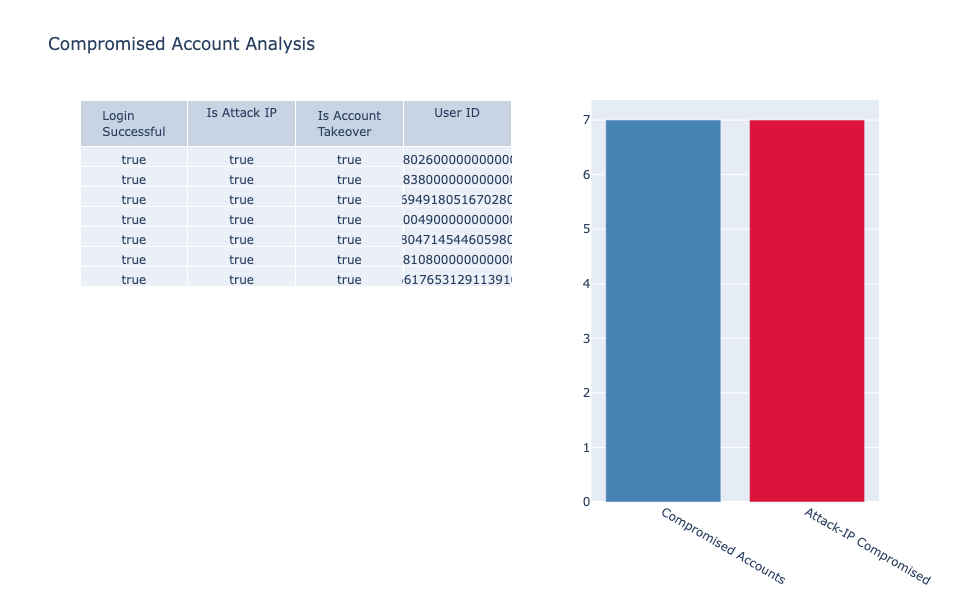

In [15]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Filter data

accounts_compromised = Attack_Attempts[
    (Attack_Attempts['Login Successful']) &
    (Attack_Attempts['Is Account Takeover']) &
    (Attack_Attempts['Is Attack IP'])
]

total_compromised = len(accounts_compromised)

attack_ip_compromised = len(
    accounts_compromised[accounts_compromised['Is Attack IP']]
)

# Create subplot figure

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "table"}, {"type": "bar"}]],
    column_widths=[0.6, 0.4]
)

# Table

fig.add_trace(
    go.Table(
        header=dict(
            values=[
                'Login Successful',
                'Is Attack IP',
                'Is Account Takeover',
                'User ID'
            ]
        ),

cells=dict(
    values=[
        accounts_compromised.head(10)['Login Successful'],
        accounts_compromised.head(10)['Is Attack IP'],
        accounts_compromised.head(10)['Is Account Takeover'],
        accounts_compromised.head(10)['User ID']
        ]
    )
),
    row=1,
    col=1
)

# Bar chart

fig.add_trace(
    go.Bar(
        x=['Compromised Accounts', 'Attack-IP Compromised'],
        y=[total_compromised, attack_ip_compromised],
        marker_color=['steelblue', 'crimson']
),
 row=1,
 col=2
)

fig.update_layout(
    title='Compromised Account Analysis',
    height=600
)

fig.show()

## How many logins are compromised 

In [8]:
Login_Compromised = Attack_Attempts[(Attack_Attempts['Is Account Takeover'] == True)]
Login_Compromised

,Login Successful,Is Attack IP,Is Account Takeover,User ID
82873,True,False,True,5.519106e+18
82947,True,False,True,-7.654600e+18
100085,True,True,True,-6.380260e+18
202905,True,False,True,4.130074e+18
273968,True,False,True,-1.369560e+17
482034,True,True,True,-5.783800e+18
482102,True,True,True,6.969492e+18
482456,True,True,True,-2.200490e+18
482566,True,True,True,5.780471e+18
483111,True,True,True,-4.181080e+18


In [9]:
Login_Compromised['Is Account Takeover'].value_counts()

Is Account Takeover
True    11
Name: count, dtype: int64

## A total number of TRUE compromises are 11

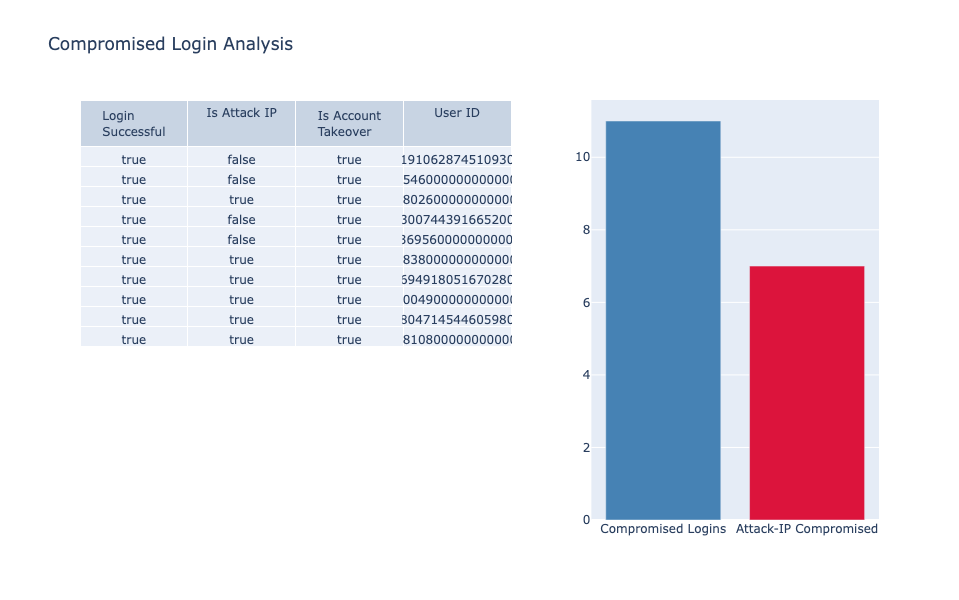

In [16]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Filter data

login_compromised = Attack_Attempts[
    (Attack_Attempts['Login Successful']) &
    (Attack_Attempts['Is Account Takeover'])
]

total_compromised = len(login_compromised)

attack_ip_compromised = len(
    login_compromised[login_compromised['Is Attack IP']]
)

# Create subplot figure

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "table"}, {"type": "bar"}]],
    column_widths=[0.6, 0.4]
)

# Table

fig.add_trace(
    go.Table(
        header=dict(
            values=[
                'Login Successful',
                'Is Attack IP',
                'Is Account Takeover',
                'User ID'
            ]
        ),

cells=dict(
    values=[
        login_compromised.head(10)['Login Successful'],
        login_compromised.head(10)['Is Attack IP'],
        login_compromised.head(10)['Is Account Takeover'],
        login_compromised.head(10)['User ID']
        ]
    )
),
    row=1,
    col=1
)

# Bar chart

fig.add_trace(
    go.Bar(
        x=['Compromised Logins', 'Attack-IP Compromised'],
        y=[total_compromised, attack_ip_compromised],
        marker_color=['steelblue', 'crimson']
),
 row=1,
 col=2
)

fig.update_layout(
    title='Compromised Login Analysis',
    height=600
)

fig.show()